In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import backend as K
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Custom Metric Functions
def recall_m(y_true, y_pred):
    true_positives = tf.keras.backend.sum(tf.keras.backend.round(tf.keras.backend.clip(y_true * y_pred, 0, 1)))
    possible_positives = tf.keras.backend.sum(tf.keras.backend.round(tf.keras.backend.clip(y_true, 0, 1)))
    return true_positives / (possible_positives + tf.keras.backend.epsilon())

def precision_m(y_true, y_pred):
    true_positives = tf.keras.backend.sum(tf.keras.backend.round(tf.keras.backend.clip(y_true * y_pred, 0, 1)))
    predicted_positives = tf.keras.backend.sum(tf.keras.backend.round(tf.keras.backend.clip(y_pred, 0, 1)))
    return true_positives / (predicted_positives + tf.keras.backend.epsilon())

def f1_m(y_true, y_pred):
    precision = precision_m(y_true, y_pred)
    recall = recall_m(y_true, y_pred)
    return 2*((precision*recall)/(precision+recall+tf.keras.backend.epsilon()))

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    validation_split=0.2,
    horizontal_flip=True,
    zoom_range=0.2,
    brightness_range=[0.8, 1.2]
)

validation_datagen = ImageDataGenerator(rescale=1./255)

# Load Data
train_generator = train_datagen.flow_from_directory(
    r'/content/drive/MyDrive/colored_images',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset = 'training'
)

validation_generator = train_datagen.flow_from_directory(
    r'/content/drive/MyDrive/colored_images',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset = 'validation',
    shuffle=False
)

Found 2931 images belonging to 5 classes.
Found 731 images belonging to 5 classes.


In [ ]:
def squeeze_excitation_block(inputs, ratio=16):
    """Squeeze-and-Excitation block to improve feature importance learning."""
    filters = inputs.shape[-1]
    x = layers.GlobalAveragePooling2D()(inputs)
    x = layers.Dense(filters // ratio, activation='relu')(x)
    x = layers.Dense(filters, activation='sigmoid')(x)
    x = layers.Reshape((1, 1, filters))(x)
    return layers.Multiply()([inputs, x])

def depthwise_separable_conv(inputs, filters, strides=1, use_se=False):
    """Depthwise Separable Convolution with optional SE block."""
    x = layers.DepthwiseConv2D(kernel_size=3, strides=strides, padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(filters, kernel_size=1, strides=1, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    if use_se:
        x = squeeze_excitation_block(x)
    return x

def build_model(input_shape=(224, 224, 3), num_classes=5):
    inputs = layers.Input(shape=input_shape)

    # Initial Standard Convolution
    x = layers.Conv2D(32, kernel_size=3, strides=2, padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # Depthwise Separable Blocks with SE
    x = depthwise_separable_conv(x, 64, strides=1, use_se=True)
    x = depthwise_separable_conv(x, 128, strides=2, use_se=True)
    x = depthwise_separable_conv(x, 128, strides=1, use_se=True)
    x = depthwise_separable_conv(x, 256, strides=2, use_se=True)
    x = depthwise_separable_conv(x, 256, strides=1, use_se=True)
    x = depthwise_separable_conv(x, 512, strides=2, use_se=True)
    x = depthwise_separable_conv(x, 512, strides=1, use_se=True)
    x = depthwise_separable_conv(x, 1024, strides=2, use_se=True)
    x = depthwise_separable_conv(x, 1024, strides=1, use_se=True)

    # Global Average Pooling and Fully Connected Layer
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return Model(inputs, outputs)

model = build_model(num_classes=train_generator.num_classes)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 112, 112,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 112, 112,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 112, 112,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv2d    │ (None, 112, 112,  │        320 │ re_lu[0][0]       │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        128 │ depthwise_conv2d… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 112, 112,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 112, 112,  │      2,112 │ re_lu_1[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 112, 112,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ re_lu_2[0][0]     │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 4)         │        260 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │        320 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 1, 64)  │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 112, 112,  │          0 │ re_lu_2[0][0],    │
│                     │ 64)               │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv2d_1  │ (None, 56, 56,    │        640 │ multiply[0][0]    │
│ (DepthwiseConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ depthwise_conv2d… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 56, 56,    │          0 │ batch_normalizat

 Total params: 2,636,985 (10.06 MB)

 Trainable params: 2,623,289 (10.01 MB)

 Non-trainable params: 13,696 (53.50 KB)

In [ ]:
# Calculate Class Weights
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weights = dict(enumerate(class_weights))

# Compile Model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=[
        tf.keras.metrics.AUC(name='acc'),
        f1_m,
        precision_m,
        recall_m
    ]
)

Epoch 1/26
92/92 ━━━━━━━━━━━━━━━━━━━━ 842s 9s/step - acc: 0.6423 - f1_m: 0.1314 - loss: 1.5935 - precision_m: 0.5196 - recall_m: 0.0778 - val_acc: 0.2739 - val_f1_m: 0.0000e+00 - val_loss: 1.7572 - val_precision_m: 0.0000e+00 - val_recall_m: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/26
92/92 ━━━━━━━━━━━━━━━━━━━━ 80s 872ms/step - acc: 0.7913 - f1_m: 0.4114 - loss: 1.4249 - precision_m: 0.9313 - recall_m: 0.2687 - val_acc: 0.2739 - val_f1_m: 0.0000e+00 - val_loss: 1.9628 - val_precision_m: 0.0000e+00 - val_recall_m: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/26
92/92 ━━━━━━━━━━━━━━━━━━━━ 81s 877ms/step - acc: 0.8165 - f1_m: 0.4505 - loss: 1.3803 - precision_m: 0.9209 - recall_m: 0.3017 - val_acc: 0.2739 - val_f1_m: 0.0000e+00 - val_loss: 2.1298 - val_precision_m: 0.0000e+00 - val_recall_m: 0.0000e+00 - learning_rate: 0.0010
Epoch 4/26
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 702ms/step - acc: 0.8434 - f1_m: 0.4925 - loss: 1.2967 - precision_m: 0.9353 - recall_m: 0.3360
Epoch 4: ReduceLROnPlateau r

Model saved successfully.
dict_keys(['acc', 'f1_m', 'loss', 'precision_m', 'recall_m', 'val_acc', 'val_f1_m', 'val_loss', 'val_precision_m', 'val_recall_m', 'learning_rate'])


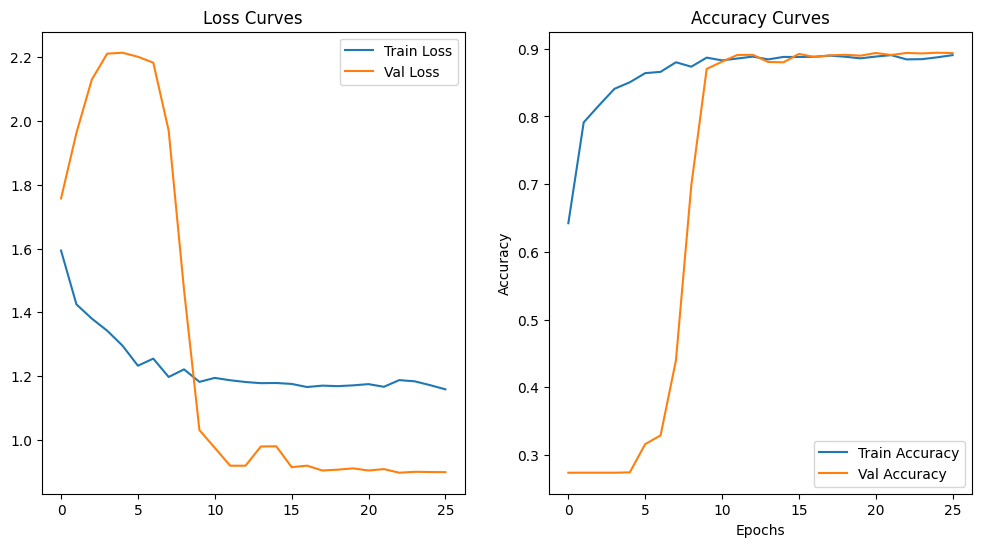

In [ ]:

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-6,
    verbose=1
)
history = model.fit(
    train_generator,
    epochs=26,
    validation_data=validation_generator,
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr]
)

model.save('diabetic_retinopathy_model_new.h5')
print("Model saved successfully.")
print(history.history.keys())
plt.figure(figsize=(12, 6))

# Loss Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Curves')
plt.legend()

# Accuracy Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['acc'], label='Train Accuracy')
plt.plot(history.history['val_acc'], label='Val Accuracy')
plt.title('Accuracy Curves')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [ ]:
import pandas as pd

# Convert history data to DataFrame
df = pd.DataFrame({
    'Epoch': range(1, len(history.history['loss']) + 1),
    'Loss': history.history['loss'],
    'Accuracy': history.history['acc'],
    'Val_Loss': history.history['val_loss'],
    'Val_Accuracy': history.history['val_acc']
})

# Save to CSV
df.to_csv("epoch_results_3.csv", index=False)

# Print preview of the saved data
print(df.head())


   Epoch      Loss  Accuracy  Val_Loss  Val_Accuracy
0      1  1.593525  0.642305  1.757190      0.273940
1      2  1.424867  0.791255  1.962774      0.273940
2      3  1.380266  0.816471  2.129792      0.273940
3      4  1.342285  0.840798  2.211259      0.273940
4      5  1.295215  0.850452  2.214176      0.274496


23/23 ━━━━━━━━━━━━━━━━━━━━ 23s 819ms/step


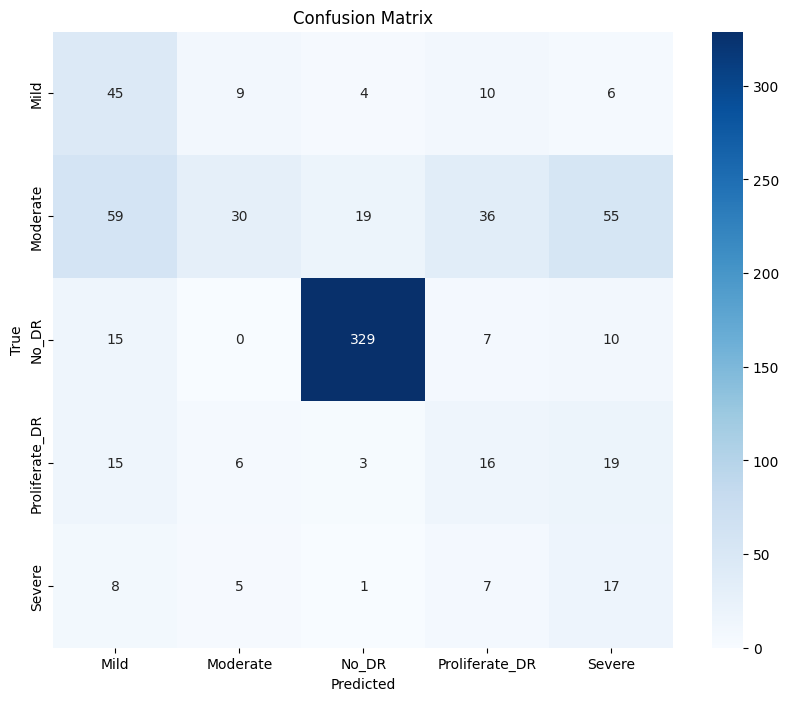

In [ ]:

validation_generator.reset()

# Get class names
class_names = list(validation_generator.class_indices.keys())

# Predict
y_pred = model.predict(validation_generator).argmax(axis=1)
y_true = validation_generator.classes

# Plot Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

Evaluating Model Robustness against SVD Compression...
Found 3662 images belonging to 5 classes.

--- Testing with Compression p=0.01 ---
115/115 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - acc: 0.7563 - f1_m: 0.4766 - loss: 2.2310 - precision_m: 0.4906 - recall_m: 0.4639
Accuracy at p=0.01: 0.7563
Found 3662 images belonging to 5 classes.

--- Testing with Compression p=0.05 ---
115/115 ━━━━━━━━━━━━━━━━━━━━ 124s 1s/step - acc: 0.8159 - f1_m: 0.4816 - loss: 1.4333 - precision_m: 0.4905 - recall_m: 0.4734
Accuracy at p=0.05: 0.8159
Found 3662 images belonging to 5 classes.

--- Testing with Compression p=0.1 ---
115/115 ━━━━━━━━━━━━━━━━━━━━ 125s 1s/step - acc: 0.8308 - f1_m: 0.4801 - loss: 1.2446 - precision_m: 0.4913 - recall_m: 0.4698
Accuracy at p=0.1: 0.8308
Found 3662 images belonging to 5 classes.

--- Testing with Compression p=0.2 ---
115/115 ━━━━━━━━━━━━━━━━━━━━ 121s 1s/step - acc: 0.8388 - f1_m: 0.4785 - loss: 1.1503 - precision_m: 0.4917 - recall_m: 0.4668
Accuracy at p=0.2: 0.8388
F

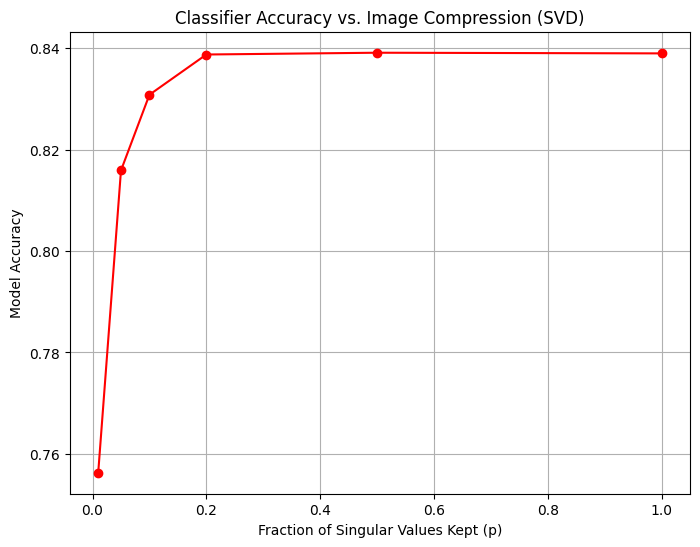

In [ ]:
def svd_compression_preprocessing(image, p_val=0.1):
    """
    1. Takes an RGB image (input from generator).
    2. Converts to Grayscale.
    3. Compresses using SVD.
    4. Converts back to 3-channel RGB format for the model.
    """
    # Image comes in as (224, 224, 3) float32 [0-1] or [0-255]
    # Convert to grayscale by averaging channels or standard luminosity
    gray = np.dot(image[...,:3], [0.2989, 0.5870, 0.1140])

    # SVD requires 2D array.
    m, n = gray.shape
    k = int(p_val * min(m, n))
    k = max(1, k)

    U, S, Vt = np.linalg.svd(gray, full_matrices=False)

    # Reconstruct
    S_k = np.diag(S[:k])
    reconstructed_gray = np.dot(U[:, :k], np.dot(S_k, Vt[:k, :]))

    # Stack grayscale back to 3 channels to match Model Input (224, 224, 3)
    reconstructed_rgb = np.stack((reconstructed_gray,)*3, axis=-1)

    return reconstructed_rgb

# --- EVALUATION LOOP ---

# Define the compression levels to test
p_test_values = [0.01, 0.05, 0.1, 0.2, 0.5, 1.0]
accuracies = []

print("Evaluating Model Robustness against SVD Compression...")

for p in p_test_values:
    # Create a wrapper lambda function to pass 'p' to the preprocessor
    preprocessing_func = lambda x: svd_compression_preprocessing(x, p_val=p)

    # New generator for this specific compression level
    test_datagen_compressed = ImageDataGenerator(
        rescale=1./255,
        preprocessing_function=preprocessing_func
    )

    test_generator_compressed = test_datagen_compressed.flow_from_directory(
        '/content/drive/MyDrive/colored_images',
        target_size=(224, 224),
        batch_size=32,
        class_mode='categorical',
        shuffle=False
    )

    # Evaluate
    print(f"\n--- Testing with Compression p={p} ---")
    results = model.evaluate(test_generator_compressed, verbose=1)

    # results[1] is usually accuracy (check your model.metrics names)
    acc = results[1]
    accuracies.append(acc)
    print(f"Accuracy at p={p}: {acc:.4f}")

# --- PLOT THE RESULTS ---
plt.figure(figsize=(8, 6))
plt.plot(p_test_values, accuracies, marker='o', linestyle='-', color='r')
plt.title('Classifier Accuracy vs. Image Compression (SVD)')
plt.xlabel('Fraction of Singular Values Kept (p)')
plt.ylabel('Model Accuracy')
plt.grid(True)
plt.show()

In [ ]:
# --- NEW CELL: LLM Setup & Configuration ---
import google.generativeai as genai
import os
from PIL import Image
from google.colab import userdata
GOOGLE_API_KEY = userdata.get('GOOGLE_API_KEY')

genai.configure(api_key=GOOGLE_API_KEY)
llm = genai.GenerativeModel('gemini-3-flash-preview')

# 2. Define human-readable labels for your 5 classes
# Mapping based on standard Diabetic Retinopathy datasets
CLASS_LABELS = {
    0: "No Diabetic Retinopathy",
    1: "Mild Non-proliferative Retinopathy",
    2: "Moderate Non-proliferative Retinopathy",
    3: "Severe Non-proliferative Retinopathy",
    4: "Proliferative Diabetic Retinopathy"
}

In [ ]:
# --- NEW CELL: Inference & LLM Integration ---
def get_prediction_and_report(image_path, model):
    # 1. Preprocess the image to match your model's input (224x224, rescaled)
    img = Image.open(image_path).resize((224, 224))
    img_array = np.array(img) / 255.0  # Rescale as per your ImageDataGenerator
    img_array = np.expand_dims(img_array, axis=0)

    # 2. Get raw prediction from your trained model
    predictions = model.predict(img_array)
    class_idx = np.argmax(predictions[0])
    confidence = predictions[0][class_idx]

    label = CLASS_LABELS[class_idx]

    # 3. Construct the prompt for the LLM
    prompt = f"""
    You are a medical diagnostic assistant. A machine learning model has analyzed a retinal scan.

    ### Analysis Results:
    - Classification: {label}
    - Confidence Score: {confidence:.2%}

    ### Instructions:
    Write a brief, professional summary (2-3 sentences) for a clinician explaining the result.
    Then, provide one sentence for the patient in plain language.
    Maintain an informative and calm tone.
    """

    # 4. Generate the post-processed report
    response = llm.generate_content(prompt)

    return {
        "raw_class": label,
        "confidence": confidence,
        "llm_report": response.text
    }

In [ ]:

test_img_path = "/content/drive/MyDrive/colored_images/No_DR/002c21358ce6.png"
# Execute the integrated workflow
result = get_prediction_and_report(test_img_path, model)

print(f"--- Model Output ---")
print(f"Prediction: {result['raw_class']} ({result['confidence']:.2%})")
print(f"\n--- LLM Post-Processed Report ---")
print(result['llm_report'])

1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step


ERROR:tornado.access:503 POST /v1beta/models/gemini-3-flash-preview:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 10550.38ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-3-flash-preview:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 30729.18ms


--- Model Output ---
Prediction: Moderate Non-proliferative Retinopathy (97.61%)

--- LLM Post-Processed Report ---
### Clinician Summary
The automated analysis indicates Moderate Non-proliferative Retinopathy with a 97.61% confidence level, suggesting the presence of microaneurysms, hemorrhages, or intraretinal microvascular abnormalities. These results warrant a clinical review of the patient’s metabolic control and a potentially shortened follow-up interval to monitor for signs of progression toward proliferative disease.

### Patient Explanation
Your eye scan shows some moderate changes caused by diabetes, so we will monitor your vision closely and work together to keep your eyes healthy.


In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import cv2

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    # 1. Create a model that maps the input image to the activations of the last conv layer
    grad_model = tf.keras.models.Model(
        model.inputs, [model.get_layer(last_conv_layer_name).output, model.output]
    )

    # 2. Record gradients for the predicted class
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    # 3. Compute gradients of the class score with respect to the feature map
    grads = tape.gradient(class_channel, last_conv_layer_output)

    # 4. Global Average Pool the gradients to get importance weights
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # 5. Multiply the feature map by the importance weights
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # 6. Normalize the heatmap
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

def display_gradcam(img_path, model):
    # Load and preprocess image
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img, (224, 224))
    img_array = np.expand_dims(img_resized / 255.0, axis=0)

    # Find the last Multiply layer dynamically
    last_layer = None
    for layer in reversed(model.layers):
        if "multiply" in layer.name:
            last_layer = layer.name
            break

    if not last_layer:
        print("Could not find a Multiply layer. Please check model architecture.")
        return

    # Generate heatmap
    preds = model.predict(img_array)
    pred_idx = np.argmax(preds[0])
    heatmap = make_gradcam_heatmap(img_array, model, last_layer)

    # Superimpose heatmap
    heatmap = np.uint8(255 * heatmap)
    jet = cm.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]
    jet_heatmap = cv2.resize(jet_heatmap, (img.shape[1], img.shape[0]))

    superimposed_img = jet_heatmap * 0.4 + (img / 255.0)
    superimposed_img = np.clip(superimposed_img, 0, 1)

    # Plot
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title(f"Original Image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(superimposed_img)
    plt.title(f"Grad-CAM (Class {pred_idx})")
    plt.axis("off")
    plt.show()

# Example Usage (replace with your test image path)
# display_gradcam("path_to_your_retina_image.png", model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)
/tmp/ipykernel_1607/1408881893.py:60: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = cm.get_cmap("jet")


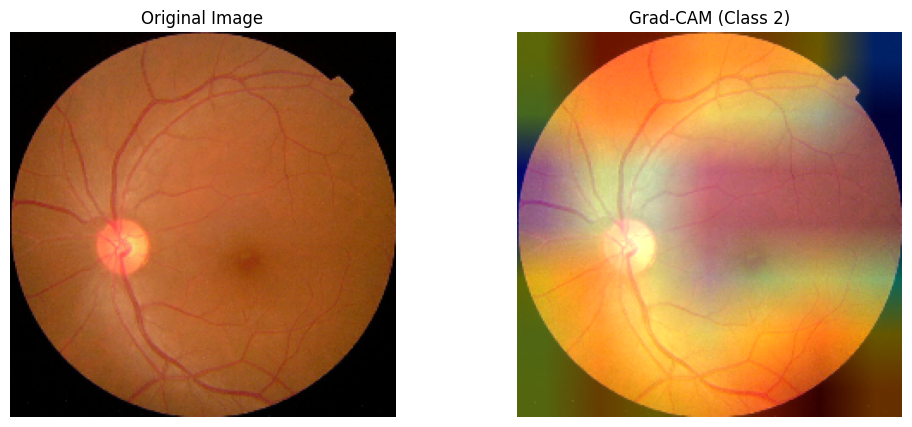

In [ ]:
# 1. Path to a test image (change this to your valid path)
test_img_path = "/content/drive/MyDrive/colored_images/No_DR/002c21358ce6.png"

# 2. Call the display_gradcam function, which handles everything
display_gradcam(test_img_path, model)